In [ ]:
import pandas as pd 

In [10]:
df = pd.read_csv('data/amazon_switchback.csv')
df['date'] = pd.to_datetime(df['date'])
jan2026 = df[(df['date'].dt.year==2026) & (df['date'].dt.month==1)]
print("Jan 2026 Ad Spend is approximately $970: Confirm in data")
print(f"Ad Spend Sum Jan 2026: {jan2026['ad_spend'].sum()}")
df.head()

Jan 2026 Ad Spend is approximately $970: Confirm in data
Ad Spend Sum Jan 2026: 969.65


,date,ad_spend,total_sales,ad_attributed_sales,treated,geo,population
0,2025-12-27,91.31,261.23,104.65,1,store_1,1
1,2025-12-28,114.98,578.30,332.02,1,store_1,1
2,2025-12-29,5.05,226.61,0.00,0,store_1,1
3,2025-12-30,47.21,323.19,241.40,1,store_1,1
4,2025-12-31,3.75,411.09,30.90,0,store_1,1


#### Set up Meridian

In [11]:
from meridian import constants
from meridian.data import load
from meridian.model import model, spec, prior_distribution

import tensorflow_probability as tfp
import numpy as np

coord_to_columns = load.CoordToColumns(
    time='date',
    geo='geo',
    population='population',
    kpi='total_sales',
    media=['ad_spend'],
    media_spend=['ad_spend'],
    controls=[],
)

media_to_channel = {'ad_spend': 'Amazon_Ads'}
media_spend_to_channel = {'ad_spend': 'Amazon_Ads'}

loader = load.CsvDataLoader(
    csv_path='data/amazon_switchback.csv',
    kpi_type='revenue',
    coord_to_columns=coord_to_columns,
    media_to_channel=media_to_channel,
    media_spend_to_channel=media_spend_to_channel,
)

data = loader.load()


/Users/jonathan/Desktop/projects/causal_inference/MMM/meridian/.venv/lib/python3.12/site-packages/meridian/data/input_data_builder.py:722: UserWarning: The `population` argument is ignored in a nationally aggregated model. It will be reset to [1, 1, ..., 1]
  warnings.warn(
/Users/jonathan/Desktop/projects/causal_inference/MMM/meridian/.venv/lib/python3.12/site-packages/meridian/data/input_data.py:516: UserWarning: Revenue from the `kpi` data is used when `kpi_type`=`revenue`. `revenue_per_kpi` is ignored.
  warnings.warn(


In [12]:
# Break-even prior: mean ROAS = 1.0, wide uncertainty
# Using your convert function: normal(1.0, 1.0) -> lognormal(-0.347, 0.833)
prior = prior_distribution.PriorDistribution(
    roi_m=tfp.distributions.LogNormal(
        loc=[-0.347],
        scale=[0.833],
        name=constants.ROI_M,
    ),
)

model_spec = spec.ModelSpec(prior=prior)

mmm = model.Meridian(input_data=data, model_spec=model_spec)

mmm.sample_prior(500)
mmm.sample_posterior(n_chains=4, n_adapt=500, n_burnin=500, n_keep=1000)


/Users/jonathan/Desktop/projects/causal_inference/MMM/meridian/.venv/lib/python3.12/site-packages/meridian/model/model.py:65: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(
I0000 00:00:1770898801.894848 9654913 service.cc:148] XLA service 0x136844ca0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770898801.894920 9654913 service.cc:156]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1770898801.911055 9654913 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/Users/jonathan/Desktop/projects/causal_inference/MMM/meridian/.venv/lib/python3.12/site-packages/meridian/model/prior_distribution.py:1264: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/Us

In [13]:
from meridian.analysis import summarizer

# Posterior vs prior ROAS
posterior_roi = mmm.inference_data.posterior.roi_m.values.flatten()
prior_roi = mmm.inference_data.prior.roi_m.values.flatten()

print("=== Amazon Ads ROAS ===")
print(f"Prior mean:      {prior_roi.mean():.2f}")
print(f"Posterior mean:   {posterior_roi.mean():.2f}")
print(f"Posterior median: {np.median(posterior_roi):.2f}")
print(f"90% CI:          [{np.percentile(posterior_roi, 5):.2f}, {np.percentile(posterior_roi, 95):.2f}]")
print(f"P(ROAS >= 1):    {(posterior_roi >= 1).mean():.1%}")
print(f"\nExperimental ROAS: 1.25")


=== Amazon Ads ROAS ===
Prior mean:      0.99
Posterior mean:   1.79
Posterior median: 1.42
90% CI:          [0.27, 4.57]
P(ROAS >= 1):    65.6%

Experimental ROAS: 1.25


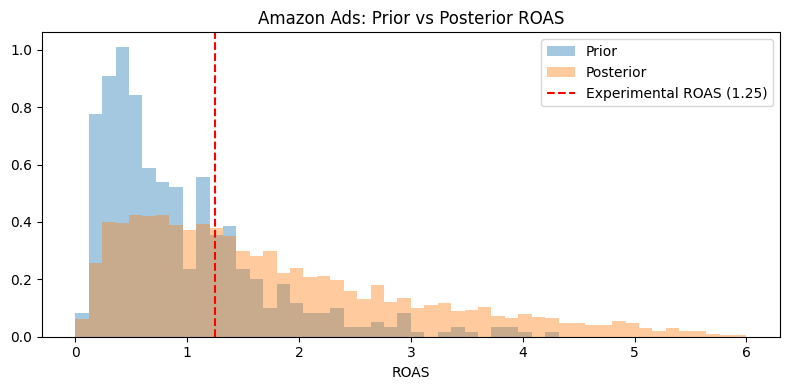

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_roi, bins=50, alpha=0.4, label='Prior', density=True, range=(0, 6))
ax.hist(posterior_roi, bins=50, alpha=0.4, label='Posterior', density=True, range=(0, 6))
ax.axvline(1.25, color='red', linestyle='--', label='Experimental ROAS (1.25)')
ax.set_xlabel('ROAS')
ax.set_title('Amazon Ads: Prior vs Posterior ROAS')
ax.legend()
plt.tight_layout()
plt.show()


In [15]:
adstock = mmm.inference_data.posterior.alpha_m.values.flatten()

print("=== Adstock Decay ===")
print(f"Posterior mean:   {adstock.mean():.3f}")
print(f"Posterior median: {np.median(adstock):.3f}")
print(f"90% CI:          [{np.percentile(adstock, 5):.3f}, {np.percentile(adstock, 95):.3f}]")


=== Adstock Decay ===
Posterior mean:   0.383
Posterior median: 0.351
90% CI:          [0.035, 0.858]


In [16]:
# 1. Adstock decay (alpha_m) — already covered
adstock = mmm.inference_data.posterior.alpha_m.values.flatten()

# 2. Half-saturation point (ec_m) — what spend level gives 50% of max effect
ec = mmm.inference_data.posterior.ec_m.values.flatten()

# 3. Saturation slope (slope_m) — shape of the response curve
slope = mmm.inference_data.posterior.slope_m.values.flatten()

# 4. ROI — already covered
roi = mmm.inference_data.posterior.roi_m.values.flatten()

print("=== Key Structural Parameters ===")
for name, param in [('Adstock Decay (alpha)', adstock), 
                     ('Half-Saturation (ec)', ec),
                     ('Slope (shape)', slope), 
                     ('ROI', roi)]:
    print(f"\n{name}:")
    print(f"  Mean:   {param.mean():.3f}")
    print(f"  Median: {np.median(param):.3f}")
    print(f"  90% CI: [{np.percentile(param, 5):.3f}, {np.percentile(param, 95):.3f}]")


=== Key Structural Parameters ===

Adstock Decay (alpha):
  Mean:   0.383
  Median: 0.351
  90% CI: [0.035, 0.858]

Half-Saturation (ec):
  Mean:   1.217
  Median: 1.152
  90% CI: [0.297, 2.368]

Slope (shape):
  Mean:   1.000
  Median: 1.000
  90% CI: [1.000, 1.000]

ROI:
  Mean:   1.792
  Median: 1.419
  90% CI: [0.270, 4.566]


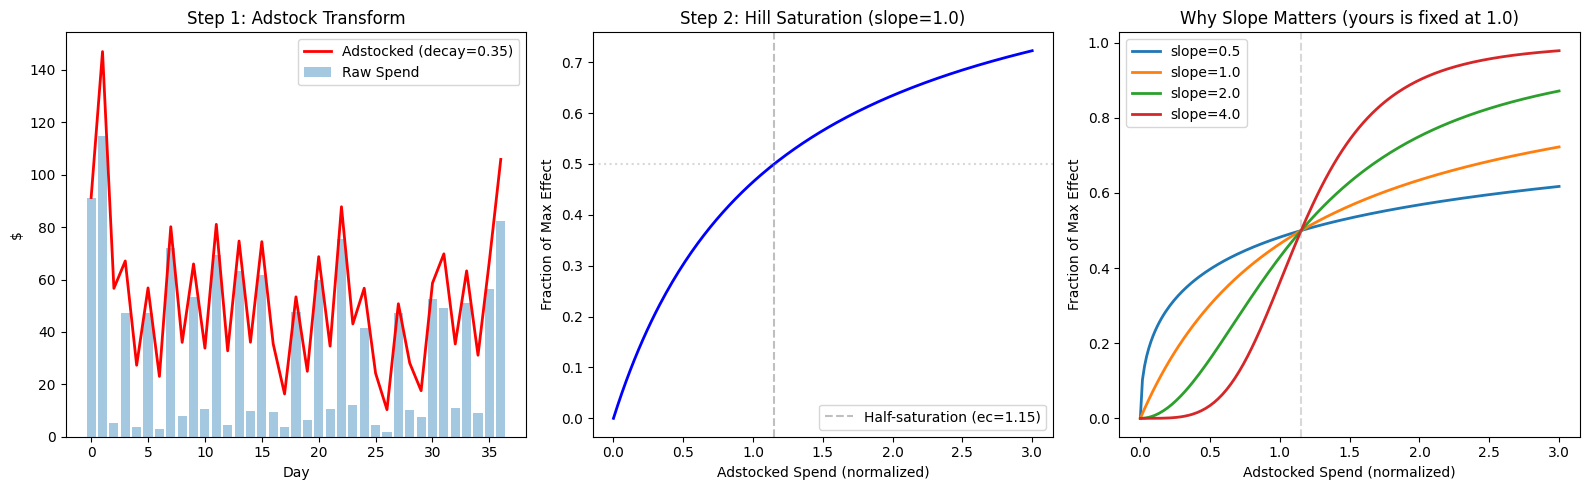

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Use posterior medians
alpha_med = np.median(adstock)  # 0.351
ec_med = np.median(ec)          # 1.152
slope_med = np.median(slope)    # 1.000

# === Panel 1: Adstock Transform ===
# Show how raw daily spend becomes "adstocked spend" with carryover
raw_spend = df['ad_spend'].values
adstocked = np.zeros_like(raw_spend)
adstocked[0] = raw_spend[0]
for t in range(1, len(raw_spend)):
    adstocked[t] = raw_spend[t] + alpha_med * adstocked[t-1]

ax = axes[0]
ax.bar(range(len(raw_spend)), raw_spend, alpha=0.4, label='Raw Spend', width=0.8)
ax.plot(adstocked, color='red', linewidth=2, label=f'Adstocked (decay={alpha_med:.2f})')
ax.set_xlabel('Day')
ax.set_ylabel('$')
ax.set_title('Step 1: Adstock Transform')
ax.legend()

# === Panel 2: Hill Saturation Curve ===
# Shows diminishing returns: how adstocked spend maps to effect
x = np.linspace(0, 3, 200)  # normalized spend
# Hill function: x^slope / (x^slope + ec^slope)
y = x**slope_med / (x**slope_med + ec_med**slope_med)

ax = axes[1]
ax.plot(x, y, linewidth=2, color='blue')
ax.axvline(ec_med, color='gray', linestyle='--', alpha=0.5, label=f'Half-saturation (ec={ec_med:.2f})')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('Adstocked Spend (normalized)')
ax.set_ylabel('Fraction of Max Effect')
ax.set_title(f'Step 2: Hill Saturation (slope={slope_med:.1f})')
ax.legend()

# === Panel 3: What different slopes would look like ===
ax = axes[2]
for s in [0.5, 1.0, 2.0, 4.0]:
    y_s = x**s / (x**s + ec_med**s)
    ax.plot(x, y_s, linewidth=2, label=f'slope={s}')
ax.axvline(ec_med, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Adstocked Spend (normalized)')
ax.set_ylabel('Fraction of Max Effect')
ax.set_title('Why Slope Matters (yours is fixed at 1.0)')
ax.legend()

plt.tight_layout()
plt.show()


In [2]:
fig, axes = plt.subplots(1, 1, figsize=(16, 5))

# Use posterior medians
alpha_med = np.median(adstock)  # 0.351
ec_med = np.median(ec)          # 1.152
slope_med = np.median(slope)    # 1.000

# === Panel 1: Adstock Transform ===
# Show how raw daily spend becomes "adstocked spend" with carryover
raw_spend = df['ad_spend'].values
adstocked = np.zeros_like(raw_spend)
adstocked[0] = raw_spend[0]
for t in range(1, len(raw_spend)):
    adstocked[t] = raw_spend[t] + alpha_med * adstocked[t-1]

ax = axes[0]
ax.bar(range(len(raw_spend)), raw_spend, alpha=0.4, label='Raw Spend', width=0.8)
ax.plot(adstocked, color='red', linewidth=2, label=f'Adstocked (decay={alpha_med:.2f})')
ax.set_xlabel('Day')
ax.set_ylabel('$')
ax.set_title('Step 1: Adstock Transform')
ax.legend()


NameError: name 'plt' is not defined

In [18]:
# === Switchback Bias from Adstock Carryover ===
#
# In a perfectly alternating on/off design, the steady-state 
# adstocked spend can be solved in closed form:
#
#   adstock_on  = (S_on + α * S_off) / (1 - α²)
#   adstock_off = (S_off + α * S_on) / (1 - α²)
#
# The difference simplifies to:
#   adstock_on - adstock_off = (S_on - S_off) / (1 + α)
#
# So carryover attenuates the measured effect by 1/(1+α).
# The corrected ROAS = measured ROAS × (1 + α)

S_on = df[df['treated'] == 1]['ad_spend'].mean()   # ~62
S_off = df[df['treated'] == 0]['ad_spend'].mean()   # ~7
experimental_roas = 1.25

# Compute correction across the full posterior of alpha
correction_factors = 1 + adstock  # vector, one per posterior draw
corrected_roas = experimental_roas * correction_factors

print("=== Switchback Carryover Correction ===")
print(f"Avg spend ON days:   ${S_on:.0f}")
print(f"Avg spend OFF days:  ${S_off:.0f}")
print(f"Raw experimental ROAS: {experimental_roas}")
print(f"\nAdstock decay (median): {np.median(adstock):.3f}")
print(f"Correction factor:      {1 + np.median(adstock):.3f}")
print(f"\nCorrected ROAS (median): {experimental_roas * (1 + np.median(adstock)):.2f}")
print(f"Corrected ROAS 90% CI:   [{np.percentile(corrected_roas, 5):.2f}, {np.percentile(corrected_roas, 95):.2f}]")
print(f"\nBreakeven ROAS (after ~50% fees): 2.00")


=== Switchback Carryover Correction ===
Avg spend ON days:   $62
Avg spend OFF days:  $7
Raw experimental ROAS: 1.25

Adstock decay (median): 0.351
Correction factor:      1.351

Corrected ROAS (median): 1.69
Corrected ROAS 90% CI:   [1.29, 2.32]

Breakeven ROAS (after ~50% fees): 2.00


#### Meridian output and diagnostics

In [19]:
from meridian.analysis import optimizer, analyzer, visualizer, summarizer, formatter 

model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics.plot_rhat_boxplot()

alt.LayerChart(...)

In [20]:
model_fit = visualizer.ModelFit(mmm)
model_fit.plot_model_fit()

/Users/jonathan/Desktop/projects/causal_inference/MMM/meridian/.venv/lib/python3.12/site-packages/meridian/analysis/analyzer.py:606: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(


alt.LayerChart(...)

In [21]:
filename = 'meridian_summary.html'
outputpath = 'output/'
mmm_summarizer = summarizer.Summarizer(mmm)
mmm_summarizer.output_model_results_summary(filename=filename, filepath=outputpath)


/Users/jonathan/Desktop/projects/causal_inference/MMM/meridian/.venv/lib/python3.12/site-packages/meridian/analysis/analyzer.py:606: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(
/Users/jonathan/Desktop/projects/causal_inference/MMM/meridian/.venv/lib/python3.12/site-packages/meridian/analysis/analyzer.py:606: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(
/Users/jonathan/Desktop/projects/causal_inference/MMM/meridian/.venv/lib/python3.12/site-packages/meridian/analysis/analyzer.py:3181: UserWarning: Effectiveness is not reported because it does not have a clear interpretation by time period.
  warnings.warn(
/Users/jonathan/Desktop/projects/causal_inference/MMM/meridian/.venv/lib/python3.12/site-packages/meridian/analysis/analyzer.py:928: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI i